<a href="https://colab.research.google.com/github/FreddieLewin23/FreddieLewin23/blob/main/SIG_data_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Data Exercise - Trade Data.csv')
df.head() # closed trade pool for 7 traders, 120,000 rows and spot
# data looks very tidy, no missing data, dates are in the correct format
df['Date'] = pd.to_datetime(df['Date'])
df.isna().sum()


,0
Date,0
TimeOfDay,0
Spot,0
BuyTrader,0
SellTrader,0


Assumptions of the data:
1. I start trading as soon as the data ends here. The strategy needs to be based off of what I have in the data without overfitting (hopefully)
2. Spot price has no pattern (ie Brownian motion etc) so strategy needs to be based off of the volume data only.
3. In live trading I will not be able to see the orders of who is trading (only see at the end of the day). If I do enter into a trade then I can see who I entered into the trade with. This will rule out intra-day strategies that rely on order flow from traders that seem profitbale in the training data. When I run backtesting on strategies I need to assume I can only see spot, time and the people I enter into trades with.

Constraints of trading:
1. up to 5 buys and 5 sells (so can do less) and need to end each day flat. Short selling allowed.
2. No trades last 30 minutes of trading (weird one here). If not flat going into last 30 minutes, I need to enter into the first trades that come up towards EoD.

Ideas and Plan of Action:
Firstly I want to have some idea of how the other traders trade with some simple analysis.

1. You can’t target flows by ID unless you “poke” the tape and see the counterparty. So strategies must either (i) probe to reveal IDs, or (ii) time-target windows where good traders are likely.
2.

In [14]:
df["Date"] = pd.to_datetime(df["Date"])
try:
    df["TimeOfDay"] = pd.to_datetime(df["TimeOfDay"]).dt.time
except Exception:
    pass
dt = pd.to_datetime(df["Date"].astype(str) + " " + df["TimeOfDay"].astype(str))
df["dt"] = dt
df = df.sort_values("dt").reset_index(drop=True)
price_col = None
for cand in ["Spot", "Price", "spot", "price", "Spot_Price"]:
    if cand in df.columns:
        price_col = cand
        break
buy_col = None
sell_col = None
for cand in df.columns:
    if "buy" in cand.lower():
        buy_col = cand
    if "sell" in cand.lower():
        sell_col = cand

# Derive day, time, and enforcement windows
df["day"] = df["dt"].dt.date
df["tod"] = df["dt"].dt.time

# Infer trading hours window (first and last time-of-day per day)
agg = df.groupby("day")["tod"].agg(["min", "max"]).reset_index()
start_t = agg["min"].mode().iloc[0]
end_t = agg["max"].mode().iloc[0]

cutoff_minutes = 30
# Compute cutoff time per day based on per-day max time
# We'll approximate by subtracting 30 minutes from each day's max and then take the mode
per_day_cutoff = (df.groupby("day")["dt"].max() - pd.Timedelta(minutes=cutoff_minutes)).dt.time
cutoff_t = per_day_cutoff.mode().iloc[0]


In [20]:
per_trader = {}
    # All trader IDs that appear anywhere
traders = pd.unique(pd.concat([df[buy_col], df[sell_col]], ignore_index=True))
traders = np.sort(traders)
# Trades where each trader appears on either side
rows = []
for tr in traders:
    buys = (df[buy_col] == tr).sum()
    sells = (df[sell_col] == tr).sum()
    total = buys + sells
    # Average time-of-day (in seconds) to see if someone is early/late concentrated
    sec = df.loc[(df[buy_col] == tr) | (df[sell_col] == tr), "dt"].dt.hour * 3600 + df.loc[(df[buy_col] == tr) | (df[sell_col] == tr), "dt"].dt.minute * 60
    avg_time_sec = sec.mean() if len(sec) else np.nan
    rows.append({"Trader": tr, "Buys": buys, "Sells": sells, "Total": total, "AvgTimeSec": avg_time_sec})
per_trader_df = pd.DataFrame(rows).sort_values("Total", ascending=False).reset_index(drop=True)

per_trader_df

,Trader,Buys,Sells,Total,AvgTimeSec
0,0,46188,56763,102951,45844.403648
1,4,21113,21113,42226,45595.765642
2,2,17878,17878,35756,45367.623336
3,5,16906,16906,33812,45617.651130
4,1,7018,7018,14036,45365.407524
5,3,10570,0,10570,45532.836329
6,6,575,570,1145,36268.873362


Looks like Trader 5 is long only, maybe something like a pension fund or retail trader just wanting long term exposure, where as trader 1, 2, 3, 4, 6 are flat overall so are market makers. trader 0 is overall short so may be something like a hedge fund who are taking positions on the direction of spot.

In [25]:
vwap = df.groupby("day")[price_col].mean().rename("DayVWAP") # volume weighted average prive
# Per-trader VWAP when they BUY vs when they SELL
t_buy_vwap = df.groupby("day").apply(lambda x: x.groupby(buy_col)[price_col].mean()).rename("BuyVWAP").reset_index()
t_sell_vwap = df.groupby("day").apply(lambda x: x.groupby(sell_col)[price_col].mean()).rename("SellVWAP").reset_index()
# Merge day-level VWAP into those
t_buy_vwap = t_buy_vwap.merge(vwap.reset_index(), on="day", how="left")
t_sell_vwap = t_sell_vwap.merge(vwap.reset_index(), on="day", how="left")
# Compute skews
t_buy_vwap["BuyMinusDayVWAP"] = t_buy_vwap["BuyVWAP"] - t_buy_vwap["DayVWAP"]
t_sell_vwap["SellMinusDayVWAP"] = t_sell_vwap["SellVWAP"] - t_sell_vwap["DayVWAP"]
# Aggregate across days
buy_edge = t_buy_vwap.groupby(t_buy_vwap.columns[1])["BuyMinusDayVWAP"].mean().rename("MeanBuySkew_vs_DayVWAP")
sell_edge = t_sell_vwap.groupby(t_sell_vwap.columns[1])["SellMinusDayVWAP"].mean().rename("MeanSellSkew_vs_DayVWAP")
# vwap_edge = pd.concat([buy_edge, sell_edge], axis=1).reset_index().rename(columns={vwap_edge.columns[0]: "Trader"})
buy_edge, sell_edge

/tmp/ipython-input-3950220791.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  t_buy_vwap = df.groupby("day").apply(lambda x: x.groupby(buy_col)[price_col].mean()).rename("BuyVWAP").reset_index()
/tmp/ipython-input-3950220791.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  t_sell_vwap = df.groupby("day").apply(lambda x: x.groupby(sell_col)[price_col].mean()).rename("SellVWAP").reset_index()


(BuyTrader
 0    0.017156
 1    0.004114
 2   -0.023379
 3    0.003429
 4   -0.013972
 5   -0.005139
 6   -0.085863
 Name: MeanBuySkew_vs_DayVWAP, dtype: float64,
 SellTrader
 0   -0.013828
 1   -0.005771
 2    0.024143
 4    0.009584
 5    0.008997
 6    0.025336
 Name: MeanSellSkew_vs_DayVWAP, dtype: float64)

In [26]:
# "Follow" vs "Fade" signal PnL proxy:
# If Trader X buys at time t and you follow (buy), close at the next trade at or after cutoff (forced EOD close).
# Similarly for sells (you sell then cover at or after cutoff).
def pnl_follow_fade(df, trader, mode="follow"):
    # mode="follow": do same side as trader; "fade": opposite side
    if price_col is None or buy_col is None or sell_col is None:
        return np.nan
    # Identify cutoff per day
    day_cut = df.groupby("day")["dt"].max() - pd.Timedelta(minutes=cutoff_minutes)
    day_cut = day_cut.to_dict()
    rets = []
    for d, day_df in df.groupby("day"):
        cut_dt = day_cut[d]
        # Entry trades for this trader during the open window (before cutoff)
        t_entries = day_df[(day_df["dt"] < cut_dt) & ((day_df[buy_col] == trader) | (day_df[sell_col] == trader))]
        if t_entries.empty:
            continue
        # Exit price = first print at or after cutoff (marketable close-out price proxy)
        exit_row = day_df[day_df["dt"] >= cut_dt].head(1)
        if exit_row.empty:
            continue
        exit_px = float(exit_row[price_col].iloc[0])
        # For each entry, compute PnL for 1-share
        for _, row in t_entries.iterrows():
            side = "buy" if row[buy_col] == trader else "sell"
            entry_px = float(row[price_col])
            if mode == "follow":
                # Do same side
                if side == "buy":
                    pnl = exit_px - entry_px
                else:
                    pnl = entry_px - exit_px
            else:  # fade
                # Do opposite side
                if side == "buy":
                    pnl = entry_px - exit_px
                else:
                    pnl = exit_px - entry_px
            rets.append(pnl)
    if len(rets) == 0:
        return np.nan
    return pd.Series(rets).mean(), pd.Series(rets).std(), len(rets)

In [27]:
ff_rows = []
for tr in per_trader_df["Trader"]:
    res_fol = pnl_follow_fade(df, tr, mode="follow")
    res_fade = pnl_follow_fade(df, tr, mode="fade")
    fol_mean, fol_std, fol_n = (res_fol if isinstance(res_fol, tuple) else (np.nan, np.nan, 0))
    fad_mean, fad_std, fad_n = (res_fade if isinstance(res_fade, tuple) else (np.nan, np.nan, 0))
    ff_rows.append({
        "Trader": tr,
        "Follow_meanPnL": fol_mean,
        "Follow_std": fol_std,
        "Follow_trades": fol_n,
        "Fade_meanPnL": fad_mean,
        "Fade_std": fad_std,
        "Fade_trades": fad_n
    })
ff_df = pd.DataFrame(ff_rows).sort_values("Follow_meanPnL", ascending=False).reset_index(drop=True)

In [31]:
ff_df
print("Per-trader activity overview", per_trader_df)
print("Per-trader 'follow vs fade' (close at daily cutoff)", ff_df)

summary = {
    "rows": len(df),
    "days": df["day"].nunique(),
    "start_day": str(df["day"].min()),
    "end_day": str(df["day"].max()),
    "start_time_mode": str(start_t),
    "end_time_mode": str(end_t),
    "cutoff_time_mode": str(cutoff_t),
    "price_col": price_col,
    "buy_col": buy_col,
    "sell_col": sell_col,
}
summary

Per-trader activity overview    Trader   Buys  Sells   Total    AvgTimeSec
0       0  46188  56763  102951  45844.403648
1       4  21113  21113   42226  45595.765642
2       2  17878  17878   35756  45367.623336
3       5  16906  16906   33812  45617.651130
4       1   7018   7018   14036  45365.407524
5       3  10570      0   10570  45532.836329
6       6    575    570    1145  36268.873362
Per-trader 'follow vs fade' (close at daily cutoff)    Trader  Follow_meanPnL  Follow_std  Follow_trades  Fade_meanPnL  Fade_std  \
0       6        0.099450    0.776424           1145     -0.099450  0.776424   
1       2        0.026677    0.573925          33052     -0.026677  0.573925   
2       4        0.013715    0.577965          38365     -0.013715  0.577965   
3       5        0.008185    0.572439          30703     -0.008185  0.572439   
4       3        0.002034    0.566220           9821     -0.002034  0.566220   
5       1       -0.009715    0.575653          12886      0.009715  0.5

{'rows': 120248,
 'days': 251,
 'start_day': '2022-01-03',
 'end_day': '2022-12-30',
 'start_time_mode': '09:30:08',
 'end_time_mode': '15:58:59',
 'cutoff_time_mode': '15:28:59',
 'price_col': 'Spot',
 'buy_col': 'BuyTrader',
 'sell_col': 'SellTrader'}

So what are we even looking at here, trader 6 stands out
Mean +0.10 on a per-trade basis vs σ around 0.78 means Sharpe of  0.13, which is enormous at the per-trade level given that each trade is big and the sample size is 1145 so big ish.

I want to follow Trader 6s trades (same-side) to the cutoff.
Traders 245 are consistent
Trader 3 is basically flat meaning neutral so maybe liquidity provision.
Traders 1 and 0 are consistently negative when followed. I dont want to follow them if I run a follwowing strategy

Fading them yields a mirror +0.010 to +0.018 edge per trade.
Trader 0 has large volume (102951 trades). If this was a proper market theyd have big influenc slippage wise if you were trading around them.

First strategy I want to test now we have this data:

Whitelist is {6, 2, 4, 5}
Blacklist is {0, 1}

Probe: take the first buy (or sell) opportunity each hour (max 2–3 pokes/day so we respect the 10-trade cap).

If counterparty is in the Whitelist: follow that trader same-side for up to N extra trades that day (e.g., N=2), but never exceed 5 buys/5 sells.

If counterparty is in Blacklist: scratch quickly (close next available opposite-side print within, say, 5 minutes) and avoid further trades in that direction that hour.

I want to check whether want i found above is consistent throughout the year of trading. once i have checked that I will backtest this idea. I do want to use some 'cooler' maths at some point. One idea I had was to use a hidden markov model with regimes where trader 6 is profitbale, trader 2 trader 4. if a HMM could pick up regime changes between when traders are working well vs not well, when i poke them to find the counterparty if they are regime then follow them, if not then carry on and get out at the next trade to not get exposure when they arent profitbale. (oh and counterparty risk isnt mentioned at all, i assume we are trading listed products to CCR isnt a worry. if it was OTC maybe wed include some sort of Credit value adjustment if they arent a great counterparty).

In [33]:
import matplotlib.pyplot as plt

df["day"] = df["dt"].dt.date
df["month"] = df["dt"].dt.to_period("M").astype(str)

price_col = "Spot" if "Spot" in df.columns else ("Price" if "Price" in df.columns else None)
buy_col = "BuyTrader" if "BuyTrader" in df.columns else [c for c in df.columns if "buy" in c.lower()][0]
sell_col = "SellTrader" if "SellTrader" in df.columns else [c for c in df.columns if "sell" in c.lower()][0]

def monthly_ff(df):
    day_cut_dt = df.groupby("day")["dt"].max() - pd.Timedelta(minutes=cutoff_minutes)
    day_cut_dt = day_cut_dt.to_dict()
    results = []

    for d, day_df in df.groupby("day"):
        if d not in day_cut_dt:
            continue
        cut_dt = day_cut_dt[d]
        exit_row = day_df[day_df["dt"] >= cut_dt].head(1)
        if exit_row.empty:
            continue
        exit_px = float(exit_row[price_col].iloc[0])
        open_df = day_df[day_df["dt"] < cut_dt]
        for _, row in open_df.iterrows():
            entry_px = float(row[price_col])
            buyer = row[buy_col]
            seller = row[sell_col]
            # Buyer follow/fade
            pnl_follow_buy = exit_px - entry_px
            pnl_fade_buy = entry_px - exit_px
            results.append({"Trader": buyer, "Side": "buy", "day": d, "FollowPnL": pnl_follow_buy, "FadePnL": pnl_fade_buy})
            # Seller follow/fade
            pnl_follow_sell = entry_px - exit_px
            pnl_fade_sell = exit_px - entry_px
            results.append({"Trader": seller, "Side": "sell", "day": d, "FollowPnL": pnl_follow_sell, "FadePnL": pnl_fade_sell})

    res_df = pd.DataFrame(results)
    res_df["month"] = pd.to_datetime(res_df["day"]).dt.to_period("M").astype(str)
    summary = res_df.groupby(["month", "Trader"])[["FollowPnL", "FadePnL"]].mean().reset_index()
    return summary

monthly_ff_df = monthly_ff(df)



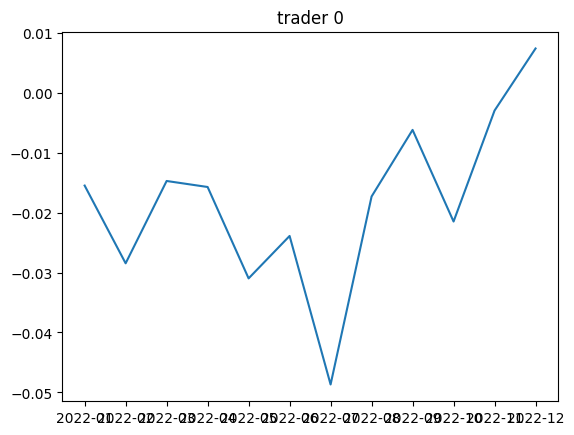

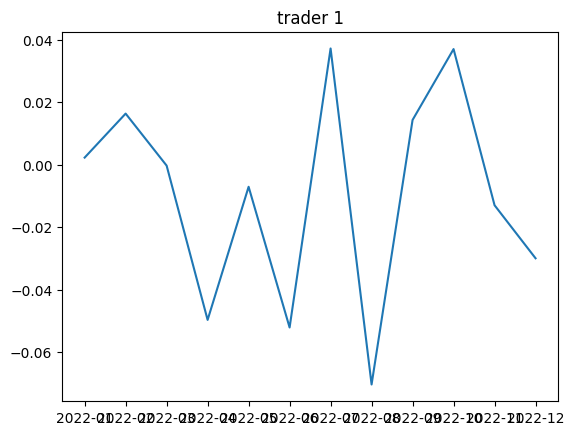

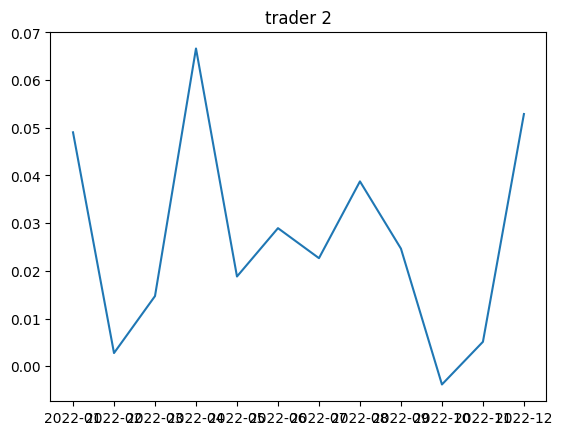

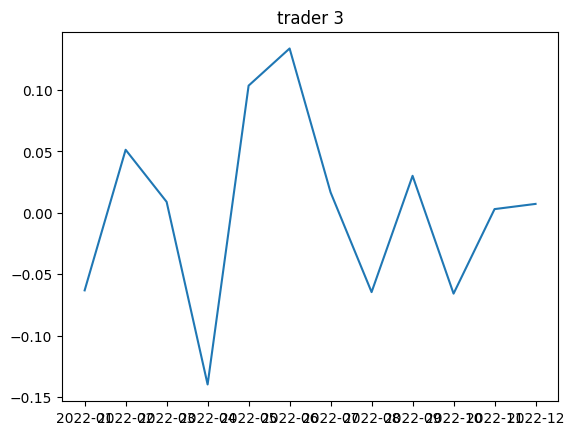

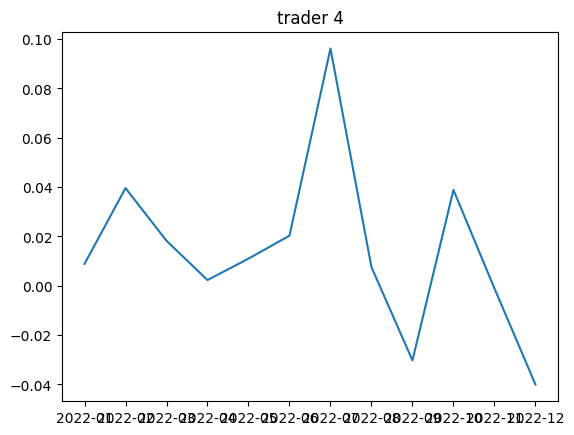

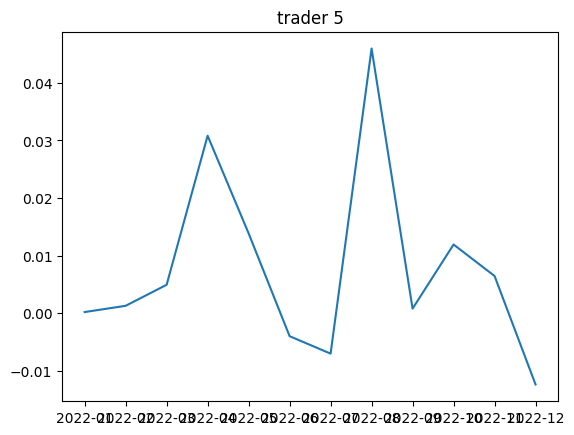

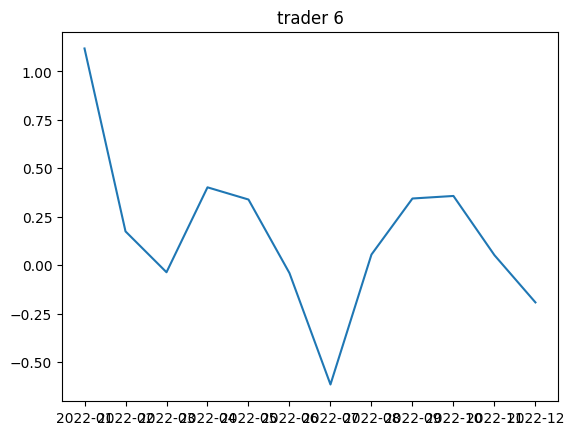

In [46]:
monthly_ff_df # 84 rows since 12 months * 7 trader
monthly_ff_df.iloc[::7, :]
monthly_ff_df.iloc[1::7, :]
plt.plot(monthly_ff_df.iloc[::7, :]['month'], monthly_ff_df.iloc[::7, :]['FollowPnL'])
plt.title('trader 0')
plt.show()
plt.plot(monthly_ff_df.iloc[1::7, :]['month'], monthly_ff_df.iloc[1::7, :]['FollowPnL'])
plt.title('trader 1')
plt.show()
plt.plot(monthly_ff_df.iloc[2::7, :]['month'], monthly_ff_df.iloc[2::7, :]['FollowPnL'])
plt.title('trader 2')
plt.show()
plt.plot(monthly_ff_df.iloc[3::7, :]['month'], monthly_ff_df.iloc[3::7, :]['FollowPnL'])
plt.title('trader 3')
plt.show()
plt.plot(monthly_ff_df.iloc[4::7, :]['month'], monthly_ff_df.iloc[4::7, :]['FollowPnL'])
plt.title('trader 4')
plt.show()
plt.plot(monthly_ff_df.iloc[5::7, :]['month'], monthly_ff_df.iloc[5::7, :]['FollowPnL'])
plt.title('trader 5')
plt.show()
plt.plot(monthly_ff_df.iloc[6::7, :]['month'], monthly_ff_df.iloc[6::7, :]['FollowPnL'])
plt.title('trader 6')
plt.show()

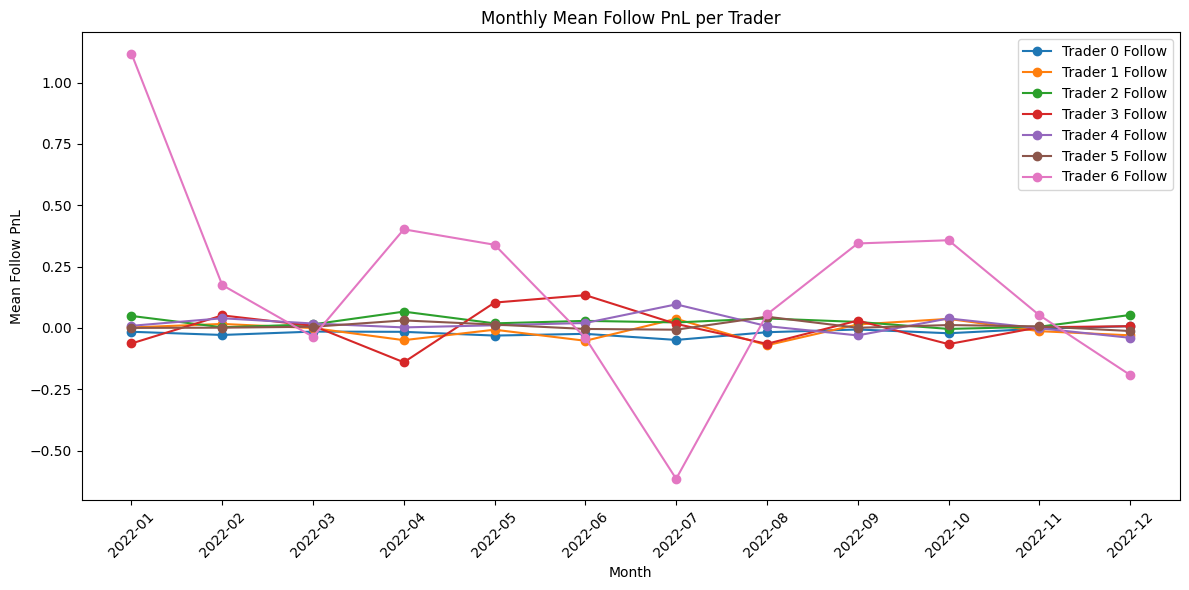

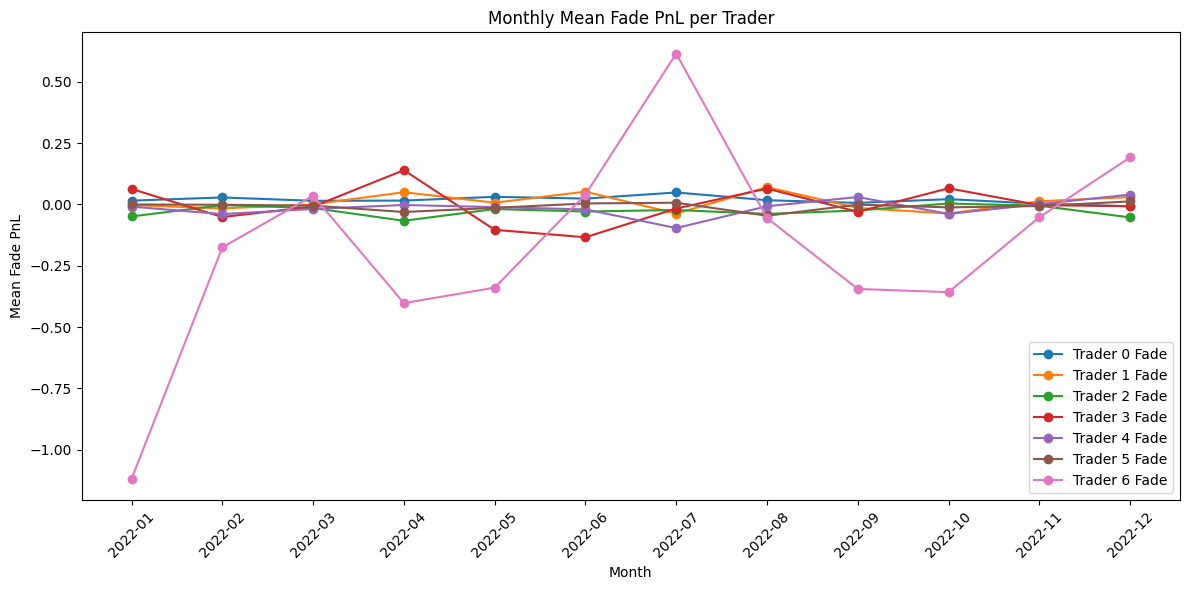

In [35]:
traders = sorted(monthly_ff_df["Trader"].unique())
plt.figure(figsize=(12, 6))
for tr in traders:
    sub = monthly_ff_df[monthly_ff_df["Trader"] == tr]
    plt.plot(sub["month"], sub["FollowPnL"], marker="o", label=f"Trader {tr} Follow")
plt.title("Monthly Mean Follow PnL per Trader")
plt.xlabel("Month")
plt.ylabel("Mean Follow PnL")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for tr in traders:
    sub = monthly_ff_df[monthly_ff_df["Trader"] == tr]
    plt.plot(sub["month"], sub["FadePnL"], marker="o", label=f"Trader {tr} Fade")
plt.title("Monthly Mean Fade PnL per Trader")
plt.xlabel("Month")
plt.ylabel("Mean Fade PnL")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

we can see here that trader 6 does very well in some period but also the worst in other when they are doing badly (very volatile trading). if i can somehow classify when trader 6 is doing well, follow them when they are. if not trader 2 is quite consistently profitable.

Strategy Idea:
1. use statistical classification (logistic regression, features i need to work out) to find when 6 is trading well. when 6 is trading well, 'poke' the market, find 6s position and follow them. if they are not trading well either fade them or trade with 2 as the person i want to poke and follow (they are consistently profitable).

Protocol
Split by month (e.g., Jan–Aug train, Sep–Dec test) to mimic forward deployment.compute all features from data up to t only. Calibrate the probability , so p = P(y=1 | x) is meaningful. Pick a probability threshold that maximizes expected PnL under your trade cap

Live Trading Policy:
Poking: try

In [50]:
def build_features(g):
    g = g.copy()
    g = g.set_index("dt")
    g = g.sort_index()

    # Price returns
    g["ret_60s"] = g[price_col].pct_change().rolling("60s").sum()
    g["ret_300s"] = g[price_col].pct_change().rolling("300s").sum()
    g["ret_900s"] = g[price_col].pct_change().rolling("900s").sum()

    # Realized volatility proxy (std of 5s returns over 5 minutes)
    r5 = g[price_col].pct_change().rolling("5s").sum()
    g["rv_300s"] = r5.rolling("300s").std()

    # Rate: prints in last 60s
    g["rate_60s"] = g[price_col].rolling("60s").count()

    # Running intraday VWAP proxy (equal-weighted: mean of prints up to now)
    g["cum_mean"] = g[price_col].expanding().mean()
    g["dist_to_vwap"] = (g[price_col] - g["cum_mean"]) / g["cum_mean"]

    # Day high/low so far & distances
    g["day_high_sofar"] = g[price_col].cummax()
    g["day_low_sofar"] = g[price_col].cummin()
    g["dist_to_high"] = (g["day_high_sofar"] - g[price_col]) / g[price_col]
    g["dist_to_low"] = (g[price_col] - g["day_low_sofar"]) / g[price_col]

    # Position in day (0..1)
    start = g.index.min()
    end = g.index.max()
    total = (end - start).total_seconds() if pd.notna(end) and pd.notna(start) else 1.0
    g["pos_in_day"] = (g.index - start).total_seconds() / max(total, 1.0)

    g = g.reset_index()
    return g

df_feat = df.groupby("day", group_keys=False).apply(build_features)
day_last_dt = df.groupby("day")["dt"].max()       # latest timestamp per day
day_cut_dt = (day_last_dt - pd.Timedelta(minutes=30)).to_dict()

def build_labels_for_trader(df_feat, trader_id, day_cut_dt):
    rows = []
    for d, g in df_feat.groupby("day"):
        cut_dt = day_cut_dt[d]
        # Exit price at/after cutoff
        exit_row = g[g["dt"] >= cut_dt].head(1)
        if exit_row.empty:
            continue
        exit_px = float(exit_row[price_col].iloc[0])

        # Only consider entries before cutoff
        open_g = g[g["dt"] < cut_dt].copy()
        # Entries where trader participates
        mask = (open_g[buy_col] == trader_id) | (open_g[sell_col] == trader_id)
        tg = open_g[mask].copy()
        if tg.empty:
            continue

        # Compute follow PnL for each occurrence
        # If trader is BUYER: follow = exit - entry; else follow = entry - exit
        is_buyer = (tg[buy_col] == trader_id).astype(int)
        entry_px = tg[price_col].astype(float)
        pnl_follow = np.where(is_buyer == 1, exit_px - entry_px, entry_px - exit_px)

        feat_cols = [
            "ret_60s","ret_300s","ret_900s","rv_300s","rate_60s",
            "dist_to_vwap","dist_to_high","dist_to_low","pos_in_day"
        ]
        X = tg[["dt","day"] + feat_cols].copy()
        X["pnl_follow"] = pnl_follow
        X["y"] = (pnl_follow >= 0.0).astype(int)  # non-negative outcome
        X["is_buyer"] = is_buyer
        rows.append(X)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    return out


/tmp/ipython-input-3870508025.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_feat = df.groupby("day", group_keys=False).apply(build_features)


In [73]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer


labels_6 = build_labels_for_trader(df_feat, 6, day_cut_dt)
labels_2 = build_labels_for_trader(df_feat, 2, day_cut_dt)

feat_cols = ["ret_60s","ret_300s","ret_900s","rv_300s","rate_60s",
             "dist_to_vwap","dist_to_high","dist_to_low","pos_in_day","is_buyer"]

def split_train_test(labels_df):
    labels_df = labels_df.copy()
    labels_df["month"] = pd.to_datetime(labels_df["dt"]).dt.month
    train = labels_df[labels_df["month"] <= 8].dropna(subset=feat_cols+["y","pnl_follow"])
    test = labels_df[labels_df["month"] >= 9].dropna(subset=feat_cols+["y","pnl_follow"])
    return train, test

train6, test6 = split_train_test(labels_6)
train2, test2 = split_train_test(labels_2)

def train_logit(train_df):
    # don't drop feature NaNs — let the imputer learn medians
    X = train_df[feat_cols].values
    y = train_df["y"].values
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(max_iter=250))
    ])
    pipe.fit(X, y)
    return pipe

In [74]:
clf6 = train_logit(train6)
clf2 = train_logit(train2)

def tau_from_train(train_df, clf):
    tmp = train_df.copy()
    if tmp.empty:
        return 0.5
    X = tmp[feat_cols].values
    p = clf.predict_proba(X)[:,1]
    R_plus = float(tmp.loc[tmp["y"]==1, "pnl_follow"].mean())
    R_minus = float(tmp.loc[tmp["y"]==0, "pnl_follow"].mean())
    tau = 0.5 if (R_plus - R_minus)==0 else max(0.0, min(1.0, (-R_minus)/(R_plus - R_minus)))
    tau_floor = float(np.nanpercentile(p, 70)) if len(p)>0 else 0.5
    return max(tau, tau_floor)

tau6 = tau_from_train(train6, clf6) if clf6 else 0.5
tau2 = tau_from_train(train2, clf2) if clf2 else 0.9

# Quick model metrics
def auc_of(clf, d):
    if clf is None or d.empty:
        return np.nan
    X = d[feat_cols].values
    y = d["y"].values
    try:
        p = clf.predict_proba(X)[:,1]
        return float(roc_auc_score(y, p))
    except Exception:
        return np.nan

In [62]:
report = {
    "train_auc_6": auc_of(clf6, train6),
    "test_auc_6": auc_of(clf6, test6),
    "tau6": float(tau6),
    "train_auc_2": auc_of(clf2, train2),
    "test_auc_2": auc_of(clf2, test2),
    "tau2": float(tau2),
}
report

{'train_auc_6': 0.6765325096430164,
 'test_auc_6': 0.5189197173736428,
 'tau6': 0.6441977273223909,
 'train_auc_2': 0.5327751514386503,
 'test_auc_2': 0.5188113602393997,
 'tau2': 0.5530876172431305}

Backtesting time

In [75]:



day_first_dt = df.groupby("day")["dt"].min().to_dict()

TP = 0.15           # take profit (in price units)
SL = -0.15          # stop loss (in price units)
TIME_STOP_SEC = 20*60
POKE_INTERVAL_SEC = 45*60
MAX_BUYS = 5
MAX_SELLS = 5
price_col = "Spot"
buy_col = "BuyTrader"
sell_col = "SellTrader"

feat_cols_live = [
    "ret_60s","ret_300s","ret_900s","rv_300s",
    "rate_60s","dist_to_vwap","dist_to_high","dist_to_low","pos_in_day"
]

def score_trader_row(row, trader_id, clf):
    """
    Build the live feature vector at this tick and get P(y=1|x).
    Returns (p, side_str) where side_str in {"buy","sell"} — the trader's side on this row.
    """
    if clf is None:
        return None, None
    x = row[feat_cols_live].astype(float).values.reshape(1, -1)
    is_buyer = 1 if row[buy_col] == trader_id else 0
    xv = np.concatenate([x, np.array([[is_buyer]])], axis=1)
    p = clf.predict_proba(xv)[:, 1][0]
    side = "buy" if is_buyer == 1 else "sell"
    return p, side

def manage_positions(entries, open_pos, buys_used, sells_used, current_dt, current_px, cut_dt):
    """
    Evaluate all open positions for TP/SL/time-stop or cutoff close.
    Returns updated (entries, open_pos, buys_used, sells_used, closed_list).
    Each element of closed_list is a dict with exit info and pnl.
    """
    closed = []
    still_open = []

    for pos in entries:
        side = pos["side"]          # "long" or "short"
        entry_px = pos["entry_px"]
        pnl_now = (current_px - entry_px) if side == "long" else (entry_px - current_px)
        elapsed = (current_dt - pos["entry_dt"]).total_seconds()

        hit_tp   = (pnl_now >= TP)
        hit_sl   = (pnl_now <= SL)
        hit_time = (elapsed >= TIME_STOP_SEC)
        hit_cut  = (current_dt >= cut_dt)

        if hit_tp or hit_sl or hit_time or hit_cut:
            pos["exit_dt"] = current_dt
            pos["exit_px"] = current_px
            pos["pnl"] = pnl_now
            pos["reason"] = "TP/SL/time/cutoff"
            closed.append(pos)
            if side == "long":
                sells_used += 1
                open_pos -= 1
            else:
                buys_used += 1
                open_pos += 1
        else:
            still_open.append(pos)

    return still_open, open_pos, buys_used, sells_used, closed


In [76]:
t_rows = []

for d, g in df_feat.groupby("day"):
    g = g.sort_values("dt").copy()
    cut_dt = day_cut_dt[d]
    start_dt = day_first_dt[d]

    # Build poke times (avoid last 30m)
    poke_times = []
    t = start_dt + pd.Timedelta(minutes=15)  # first poke not right at open
    while t < (cut_dt - pd.Timedelta(minutes=1)):
        poke_times.append(t)
        t += pd.Timedelta(seconds=POKE_INTERVAL_SEC)

    buys_used = 0
    sells_used = 0
    open_pos = 0
    entries = []
    next_poke_idx = 0

    for _, row in g.iterrows():
        dt = row["dt"]
        px = float(row[price_col])

        # 1) manage open positions first
        entries, open_pos, buys_used, sells_used, closed_now = manage_positions(
            entries, open_pos, buys_used, sells_used, dt, px, cut_dt
        )
        for c in closed_now:
            bt_rows.append({
                "day": d, "entry_dt": c["entry_dt"], "exit_dt": c["exit_dt"],
                "side": c["side"], "entry_px": c["entry_px"], "exit_px": c["exit_px"],
                "pnl": c["pnl"], "reason": c["reason"]
            })

        # 2) no new entries inside last 30m
        if dt >= cut_dt:
            continue

        # 3) poke condition: time reached + capacity remaining
        should_poke = (next_poke_idx < len(poke_times)) and (dt >= poke_times[next_poke_idx])
        if not should_poke:
            continue
        next_poke_idx += 1

        # "Reveal" who we just interacted with — in this simplified emulation
        revealed_6 = (row[buy_col] == 6) or (row[sell_col] == 6)
        revealed_2 = (row[buy_col] == 2) or (row[sell_col] == 2)

        took_trade = False

        # Try Trader 6 first
        if revealed_6 and (buys_used < MAX_BUYS or sells_used < MAX_SELLS):
            p6, side6 = score_trader_row(row, 6, clf6)
            if (p6 is not None) and (p6 >= tau6):
                if side6 == "buy" and buys_used < MAX_BUYS:
                    entries.append({"side": "long", "entry_dt": dt, "entry_px": px})
                    buys_used += 1
                    open_pos += 1
                    took_trade = True
                elif side6 == "sell" and sells_used < MAX_SELLS:
                    entries.append({"side": "short", "entry_dt": dt, "entry_px": px})
                    sells_used += 1
                    open_pos -= 1
                    took_trade = True

        # Fallback: Trader 2
        if (not took_trade) and revealed_2 and (buys_used < MAX_BUYS or sells_used < MAX_SELLS):
            p2, side2 = score_trader_row(row, 2, clf2)
            if (p2 is not None) and (p2 >= tau2):
                if side2 == "buy" and buys_used < MAX_BUYS:
                    entries.append({"side": "long", "entry_dt": dt, "entry_px": px})
                    buys_used += 1
                    open_pos += 1
                    took_trade = True
                elif side2 == "sell" and sells_used < MAX_SELLS:
                    entries.append({"side": "short", "entry_dt": dt, "entry_px": px})
                    sells_used += 1
                    open_pos -= 1
                    took_trade = True
    exit_row = g[g["dt"] >= cut_dt].head(1)
    if not exit_row.empty:
        exit_dt = exit_row["dt"].iloc[0]
        exit_px = float(exit_row[price_col].iloc[0])
        for pos in entries:
            side = pos["side"]
            entry_px = pos["entry_px"]
            pnl = (exit_px - entry_px) if side == "long" else (entry_px - exit_px)
            bt_rows.append({
                "day": d, "entry_dt": pos["entry_dt"], "exit_dt": exit_dt,
                "side": side, "entry_px": entry_px, "exit_px": exit_px,
                "pnl": pnl, "reason": "cutoff_force"
            })
        entries = []


{'n_trades': 188, 'n_days': 130, 'avg_pnl_per_trade': 0.03053191489361707, 'total_pnl': 5.740000000000009, 'hit_rate': 0.601063829787234, 'tau6': 0.6441977273223909, 'tau2': 0.5530876172431305}


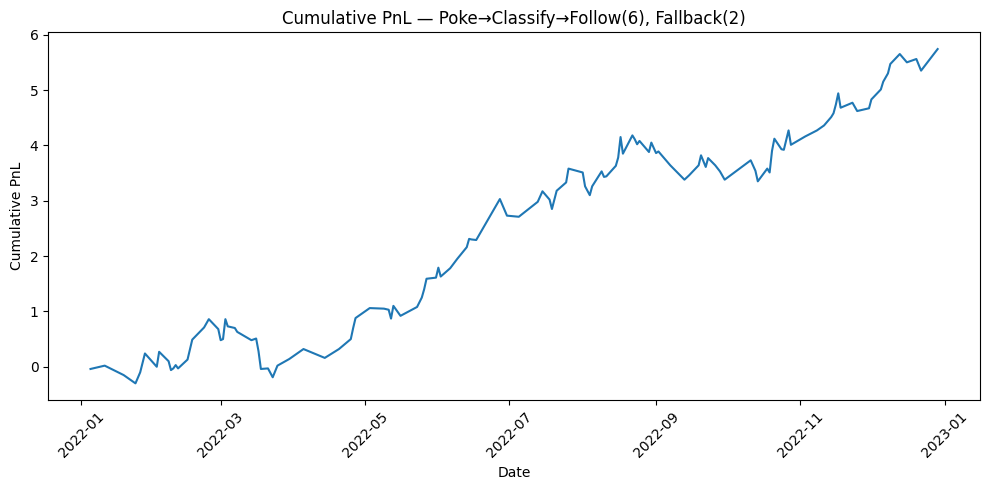

In [77]:
bt = pd.DataFrame(bt_rows).sort_values("entry_dt").reset_index(drop=True)
bt["date"] = pd.to_datetime(bt["day"])
daily = bt.groupby("date")["pnl"].sum().reset_index().sort_values("date")
daily["cum_pnl"] = daily["pnl"].cumsum()

print({
    "n_trades": int(len(bt)),
    "n_days": int(bt["day"].nunique()) if len(bt) else 0,
    "avg_pnl_per_trade": float(bt["pnl"].mean()) if len(bt) else float("nan"),
    "total_pnl": float(bt["pnl"].sum()) if len(bt) else float("nan"),
    "hit_rate": float((bt["pnl"] > 0).mean()) if len(bt) else float("nan"),
    "tau6": float(tau6), "tau2": float(tau2)
})

# (Optional) plot
plt.figure(figsize=(10,5))
plt.plot(daily["date"], daily["cum_pnl"])
plt.title("Cumulative PnL — Poke→Classify→Follow(6), Fallback(2)")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()